In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install transformers
!pip install -U gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 91.3 MB/s eta 0:00:00


In [3]:
import tensorflow as tf
import numpy as np
import random
import os

SEED = 2025

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

In [4]:
import tensorflow as tf

print("GPU available:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        print(e)

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
1 Physical GPUs, 1 Logical GPUs


In [5]:
import tensorflow as tf

dataset_train = tf.data.Dataset.load("/content/drive/MyDrive/Universidad/Investigacion/tf_datasets_3/train")

In [6]:
from tensorflow.keras.layers import Dense, Input, Dropout, Bidirectional, LSTM, Embedding, BatchNormalization, Reshape, Conv2D, MaxPool2D, concatenate, Flatten
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, MaxPooling1D, Input, Bidirectional, GRU, Flatten, concatenate, BatchNormalization, Dense, LeakyReLU, Activation
from tensorflow.keras.models import Model
from keras import regularizers

num_classes = 8

def create_input_branch(input_shape, name):
    input_layer = Input(shape=input_shape, name=name)
    dense1 = Dense(10000)(input_layer)
    batch1 = BatchNormalization()(dense1)
    activation1 = Activation('relu')(batch1)
    drop1 = Dropout(0.5)(activation1)

    dense2 = Dense(1000)(drop1)
    batch2 = BatchNormalization()(dense2)
    activation2 = Activation('relu')(batch2)
    drop2 = Dropout(0.2)(activation2)

    dense3 = Dense(10000)(drop2)
    batch3 = BatchNormalization()(dense3)
    activation3 = Activation('relu')(batch3)
    drop3 = Dropout(0.2)(activation3)
    return input_layer, drop3

input_nl, output_nl = create_input_branch((768,), "nl")
input_pl, output_pl = create_input_branch((768,), "pl")
input_initial, output_initial = create_input_branch((768,), "initial")
input_transformation, output_transformation = create_input_branch((768,), "transformation")
input_js, output_js = create_input_branch((768,), "js")
input_final, output_final = create_input_branch((768,), "final")


concat = concatenate([output_nl, output_pl, output_initial, output_transformation, output_js, output_final])

output = Dense(num_classes)(concat)
output = BatchNormalization()(output)
output = Activation('softmax')(output)

model = Model(inputs=[input_nl, input_pl, input_initial, input_transformation, input_js, input_final], outputs=output)

In [7]:
%%time
from tensorflow.keras.optimizers import Adam
adam = Adam(learning_rate=0.00001)

model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy', tf.keras.metrics.F1Score(average='macro')])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ nl (InputLayer)     │ (None, 768)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pl (InputLayer)     │ (None, 768)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial             │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformation      │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ js (InputLayer)     │ (None, 768)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final (InputLayer)  │ (None, 768)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10000)     │  7,690,000 │ nl[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10000)     │  7,690,000 │ pl[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 10000)     │  7,690,000 │ initial[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 10000)     │  7,690,000 │ transformation[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 10000)     │  7,690,000 │ js[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 10000)     │  7,690,000 │ final[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10000)     │     40,000 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10000)     │     40,000 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10000)     │     40,000 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10000)     │     40,000 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10000)     │     40,000 │ dense_12[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10000)     │     40,000 │ dense_15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 10000)     │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 10000)     │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 167,190,040 (637.78 MB)

 Trainable params: 166,938,024 (636.82 MB)

 Non-trainable params: 252,016 (984.44 KB)

CPU times: user 78.6 ms, sys: 3.58 ms, total: 82.2 ms
Wall time: 83.1 ms


In [8]:
from tensorflow.keras.callbacks import EarlyStopping

total_size = dataset_train.reduce(0, lambda x, _: x + 1).numpy()
val_size = int(0.2 * total_size)

dataset_train = dataset_train.shuffle(
    buffer_size=total_size,
    seed=SEED,
    reshuffle_each_iteration=False
)

val_dataset = dataset_train.take(val_size)
train_dataset = dataset_train.skip(val_size)



epochs=150

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)


history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stop]
)

Epoch 1/150
991/991 ━━━━━━━━━━━━━━━━━━━━ 131s 116ms/step - accuracy: 0.3297 - f1_score: 0.3284 - loss: 1.7502 - val_accuracy: 0.6193 - val_f1_score: 0.6191 - val_loss: 1.1971
Epoch 2/150
991/991 ━━━━━━━━━━━━━━━━━━━━ 114s 115ms/step - accuracy: 0.5858 - f1_score: 0.5839 - loss: 1.2846 - val_accuracy: 0.7589 - val_f1_score: 0.7568 - val_loss: 0.9758
Epoch 3/150
991/991 ━━━━━━━━━━━━━━━━━━━━ 115s 115ms/step - accuracy: 0.6996 - f1_score: 0.6985 - loss: 1.1410 - val_accuracy: 0.8148 - val_f1_score: 0.8134 - val_loss: 0.8851
Epoch 4/150
991/991 ━━━━━━━━━━━━━━━━━━━━ 115s 115ms/step - accuracy: 0.7562 - f1_score: 0.7552 - loss: 1.0632 - val_accuracy: 0.8353 - val_f1_score: 0.8336 - val_loss: 0.8322
Epoch 5/150
991/991 ━━━━━━━━━━━━━━━━━━━━ 115s 115ms/step - accuracy: 0.7862 - f1_score: 0.7855 - loss: 1.0130 - val_accuracy: 0.8536 - val_f1_score: 0.8524 - val_loss: 0.7898
Epoch 6/150
991/991 ━━━━━━━━━━━━━━━━━━━━ 115s 115ms/step - accuracy: 0.8116 - f1_score: 0.8110 - loss: 0.9748 - val_accuracy:

In [9]:
model.save('/content/drive/MyDrive/Universidad/Investigacion/models/codet5_1.keras')

In [10]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_f1 = history.history['f1_score']
val_f1 = history.history['val_f1_score']

In [11]:
length = len(history.history['accuracy'])

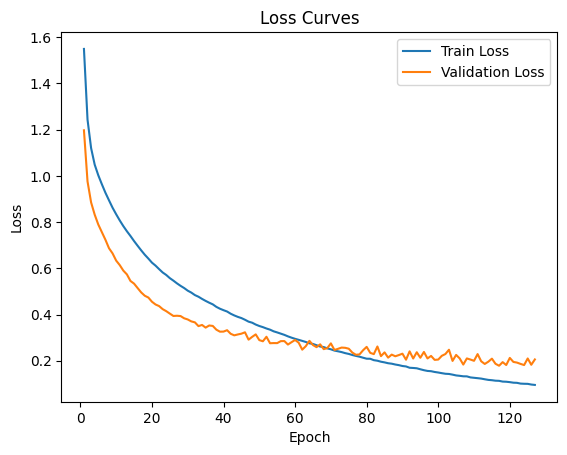

In [12]:
import matplotlib.pyplot as plt

plt.plot(range(1, length+1), train_loss, label='Train Loss')
plt.plot(range(1, length+1), val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

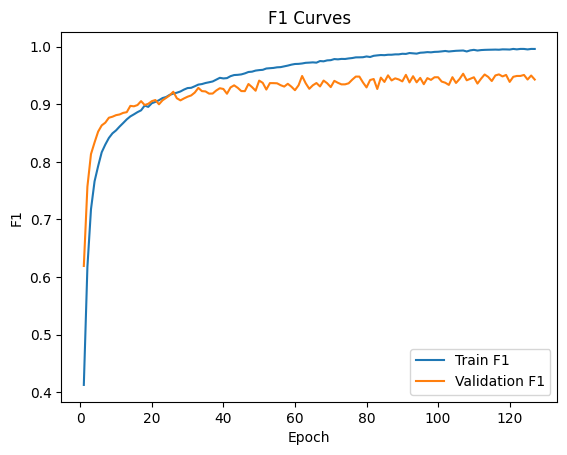

In [13]:
import matplotlib.pyplot as plt

plt.plot(range(1, length+1), train_f1, label='Train F1')
plt.plot(range(1, length+1), val_f1, label='Validation F1')
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.title('F1 Curves')
plt.legend()
plt.show()